# CIHA: o que existe além do SUS — e por que usar com cuidado

**A pergunta:** o SIH mostra tudo o que o SUS pagou. Mas os mesmos hospitais
atendem convênios e pacientes particulares, e essa parte não aparece ali. O
CIHA foi criado justamente para registrar o atendimento **não financiado pelo
SUS** nos estabelecimentos que integram a rede — de modo que o Ministério da
Saúde enxergue o uso real da capacidade instalada.

É a base menos conhecida do conjunto, e a que mais exige cautela. Este notebook
mostra o que ela entrega, o que ela não entrega, e como comparar honestamente
com o SIH.

**Fonte:** Comunicação de Internação Hospitalar e Ambulatorial (CIHA/DATASUS) e
Sistema de Informações Hospitalares (SIH/SUS).

**Tempo estimado:** 4 a 8 minutos.

**O que você leva daqui:** o método de descobrir o significado de um campo pela
evidência interna, a comparação CIHA × SIH no mesmo mês e no mesmo estado, e
uma medida objetiva da instabilidade da base.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
UF = "PR"
print(f"Estado analisado: {UF}")

Estado analisado: PR


## 2. A primeira armadilha está na chamada

O CIHA é a única base em que o parâmetro `group` tem um valor padrão — e esse
valor devolve **zero linhas**. É preciso passar `group=None` explicitamente.
Quem não sabe disso conclui que não há dados para o período.

In [5]:
from pysus import ciha, list_files

catalogo = list_files(dataset="ciha", state=UF)
catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                       for n in catalogo["name"]]
catalogo["mes"] = pd.to_numeric(catalogo["arquivo"].str[8:10], errors="coerce")
catalogo = catalogo.dropna(subset=["year", "mes"])

# Vamos comparar CIHA com SIH, então precisamos de uma competência que exista
# nas duas bases — e o SIH publica o grupo RD em pouquíssimos meses.
catalogo_sih = list_files(dataset="sih", state=UF)
catalogo_sih["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                           for n in catalogo_sih["name"]]
rd_sih = catalogo_sih[catalogo_sih["arquivo"].str.upper().str.startswith("RD")].copy()
rd_sih["mes"] = pd.to_numeric(rd_sih["arquivo"].str[6:8], errors="coerce")
rd_sih = rd_sih.dropna(subset=["year", "mes"])

competencias_ciha = {(int(a), int(m)) for a, m in zip(catalogo["year"], catalogo["mes"])}
competencias_sih = {(int(a), int(m)) for a, m in zip(rd_sih["year"], rd_sih["mes"])}
comuns = sorted(competencias_ciha & competencias_sih)

ANO, MES = comuns[-1]

print(f"Arquivos do CIHA para {UF}: {len(catalogo)}, "
      f"de {int(catalogo['year'].min())} a {int(catalogo['year'].max())}")
print(f"Competências com internações no SIH (grupo RD): {len(competencias_sih)}")
print(f"Competências presentes nas duas bases: {len(comuns)}")
print(f"Escolhida para a comparação: {MES:02d}/{ANO}\n")

com_padrao = ciha(UF, ANO, MES)                 # group padrão = "CIHA"
sem_group = ciha(UF, ANO, MES, group=None)      # o jeito certo
print(f"ciha(UF, ANO, MES)              -> {len(com_padrao)} arquivo(s)")
print(f"ciha(UF, ANO, MES, group=None)  -> {len(sem_group)} arquivo(s)")

Arquivos do CIHA para PR: 186, de 2011 a 2026
Competências com internações no SIH (grupo RD): 135
Competências presentes nas duas bases: 33
Escolhida para a comparação: 02/2026



ciha(UF, ANO, MES)              -> 0 arquivo(s)
ciha(UF, ANO, MES, group=None)  -> 1 arquivo(s)


In [6]:
caminho = sem_group[0].replace("\\", "/")
registros = con.execute(f"SELECT count(*) FROM read_parquet('{caminho}')").fetchone()[0]
colunas = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{caminho}')").df()

print(f"{os.path.basename(caminho)}: {mil(registros)} registros, "
      f"{len(colunas)} colunas\n")
print(list(colunas["column_name"]))

CIHAPR2602.parquet: 17.668 registros, 30 colunas

['ANO_CMPT', 'MES_CMPT', 'ESPEC', 'CGC_HOSP', 'MUNIC_RES', 'NASC', 'SEXO', 'UTI_MES_TO', 'UTI_INT_TO', 'PROC_REA', 'QT_PROC', 'DT_ATEND', 'DT_SAIDA', 'DIAG_PRINC', 'DIAG_SECUN', 'COBRANCA', 'NATUREZA', 'GESTAO', 'MUNIC_MOV', 'COD_IDADE', 'IDADE', 'DIAS_PERM', 'MORTE', 'NACIONAL', 'CAR_INT', 'HOMONIMO', 'CNES', 'FONTE', 'CGC_CONSOR', 'MODALIDADE']


## 3. Descobrindo o que um campo significa sem a legenda

O campo `MODALIDADE` tem três valores e nenhuma legenda no arquivo. Em vez de
adivinhar, deixamos os outros campos responderem: uma **internação** tem dias
de permanência e pode terminar em óbito; um **atendimento ambulatorial** não
tem nem uma coisa nem outra.

In [7]:
modalidades = con.execute(f"""
    SELECT MODALIDADE AS codigo,
           count(*) AS registros,
           round(avg(TRY_CAST(DIAS_PERM AS DOUBLE)), 2) AS dias_medios,
           sum(CASE WHEN MORTE = '1' THEN 1 ELSE 0 END) AS obitos,
           round(sum(CASE WHEN DIAG_PRINC IS NULL OR DIAG_PRINC = ''
                          THEN 1 ELSE 0 END) * 100.0 / count(*), 1) AS pct_sem_cid
    FROM read_parquet('{caminho}')
    GROUP BY 1 ORDER BY registros DESC
""").df()
modalidades

,codigo,registros,dias_medios,obitos,pct_sem_cid
0,01,14309,0.00,0.0,26.2
1,02,2759,2.01,41.0,0.8
2,00,600,NaN,0.0,100.0


A tabela responde sozinha: o código com dias de permanência e óbitos é a
**internação**; o que tem zero dias e nenhum óbito é o **atendimento
ambulatorial**; e o terceiro, sem CID em 100% dos registros, é um resíduo sem
informação clínica útil.

Nenhum manual foi consultado — e mesmo assim a leitura é segura, porque cada
conclusão se apoia em outro campo do próprio arquivo.

In [8]:
INTERNACAO = modalidades.loc[modalidades["obitos"].idxmax(), "codigo"]
AMBULATORIAL = modalidades[
    (modalidades["codigo"] != INTERNACAO) & (modalidades["pct_sem_cid"] < 100)
]["codigo"].iloc[0]

print(f"Código de internação identificado:   {INTERNACAO}")
print(f"Código de ambulatorial identificado: {AMBULATORIAL}")

Código de internação identificado:   02
Código de ambulatorial identificado: 01


## 4. CIHA e SIH lado a lado

Agora a comparação que dá sentido à base: as internações do CIHA e as do SIH,
no **mesmo estado e no mesmo mês**. O SIH é a produção paga pelo SUS; o CIHA, o
que ficou de fora.

In [9]:
from pysus import sih

def arquivo_rd(uf, ano, mes):
    "O arquivo de internações do SIH — nunca o primeiro da lista, que é o SP."
    for c in sih(uf, ano, mes):
        if os.path.basename(c).upper().startswith("RD"):
            return c.replace("\\", "/")
    return None

rd = arquivo_rd(UF, ANO, MES)
print(f"SIH, grupo RD, {MES:02d}/{ANO}: "
      f"{os.path.basename(rd) if rd else 'não publicado para esta competência'}")

SIH, grupo RD, 02/2026: RDPR2602.parquet


In [10]:
ciha_int = con.execute(f"""
    SELECT count(*) AS internacoes,
           round(avg(TRY_CAST(DIAS_PERM AS DOUBLE)), 1) AS permanencia,
           round(sum(CASE WHEN MORTE = '1' THEN 1 ELSE 0 END) * 100.0
                 / count(*), 2) AS letalidade,
           count(DISTINCT CNES) AS estabelecimentos,
           count(DISTINCT MUNIC_RES) AS municipios
    FROM read_parquet('{caminho}')
    WHERE MODALIDADE = '{INTERNACAO}'
""").df().iloc[0]

sih_int = con.execute(f"""
    SELECT count(*) AS internacoes,
           round(avg(TRY_CAST(DIAS_PERM AS DOUBLE)), 1) AS permanencia,
           round(sum(CASE WHEN MORTE = '1' THEN 1 ELSE 0 END) * 100.0
                 / count(*), 2) AS letalidade,
           count(DISTINCT CNES) AS estabelecimentos,
           count(DISTINCT MUNIC_RES) AS municipios
    FROM read_parquet('{rd}')
""").df().iloc[0]

comparacao = pd.DataFrame({"CIHA (não SUS)": ciha_int, "SIH (SUS)": sih_int})
comparacao.index = ["Internações", "Permanência média (dias)",
                    "Letalidade (%)", "Estabelecimentos", "Municípios de residência"]
comparacao["CIHA em % do SIH"] = (
    comparacao["CIHA (não SUS)"] / comparacao["SIH (SUS)"] * 100).round(1)
comparacao

,CIHA (não SUS),SIH (SUS),CIHA em % do SIH
Internações,2759.00,88206.00,3.1
Permanência média (dias),2.00,4.00,50.0
Letalidade (%),1.49,3.49,42.7
Estabelecimentos,6.00,291.00,2.1
Municípios de residência,137.00,677.00,20.2


O contraste é a informação. O CIHA registra uma fração pequena do que o SIH
registra, e vem de um punhado de estabelecimentos contra centenas. Isso **não**
significa que o atendimento privado seja pequeno — significa que o CIHA capta
pouco dele. É uma comunicação de preenchimento irregular, e o próprio
Ministério da Saúde trata a base como complementar, nunca como censo.

Repare também na permanência e na letalidade, ambas cerca de metade das do SIH.
Não é sinal de que se trate melhor fora do SUS: é composição. O que chega ao
CIHA são internações mais curtas e menos graves, de poucos serviços.

In [11]:
def perfil_cid(arquivo, filtro=""):
    return con.execute(f"""
        SELECT substr(DIAG_PRINC, 1, 1) AS capitulo, count(*) AS n
        FROM read_parquet('{arquivo}')
        WHERE DIAG_PRINC IS NOT NULL AND DIAG_PRINC <> '' {filtro}
        GROUP BY 1 ORDER BY n DESC LIMIT 8
    """).df().set_index("capitulo")["n"]

LETRAS = {
    "A": "Infecciosas", "B": "Infecciosas", "C": "Neoplasias",
    "D": "Sangue e neoplasias benignas", "E": "Endócrinas", "F": "Mentais",
    "G": "Sistema nervoso", "H": "Olho e ouvido",
    "I": "Circulatório", "J": "Respiratório",
    "K": "Digestivo", "L": "Pele", "M": "Osteomuscular", "N": "Geniturinário",
    "O": "Gravidez e parto", "P": "Perinatal", "Q": "Malformações",
    "R": "Mal definidas", "S": "Lesões", "T": "Lesões", "Z": "Outros contatos",
}

cid_ciha = perfil_cid(caminho, f"AND MODALIDADE = '{INTERNACAO}'")
cid_sih = perfil_cid(rd)

quadro = pd.DataFrame({
    "CIHA": cid_ciha / cid_ciha.sum() * 100,
    "SIH": cid_sih / cid_sih.sum() * 100,
}).fillna(0).round(1)
quadro.index = [f"{i} — {LETRAS.get(i, '?')}" for i in quadro.index]
quadro = quadro.sort_values("CIHA", ascending=False)

print("Composição das internações por letra inicial da CID-10 (%)\n")
quadro

Composição das internações por letra inicial da CID-10 (%)



,CIHA,SIH
N — Geniturinário,19.0,12.5
H — Olho e ouvido,18.0,0.0
I — Circulatório,14.5,16.8
O — Gravidez e parto,10.6,15.1
K — Digestivo,10.5,15.7
R — Mal definidas,9.9,0.0
M — Osteomuscular,9.0,0.0
S — Lesões,8.4,11.5
A — Infecciosas,0.0,6.1
C — Neoplasias,0.0,10.6


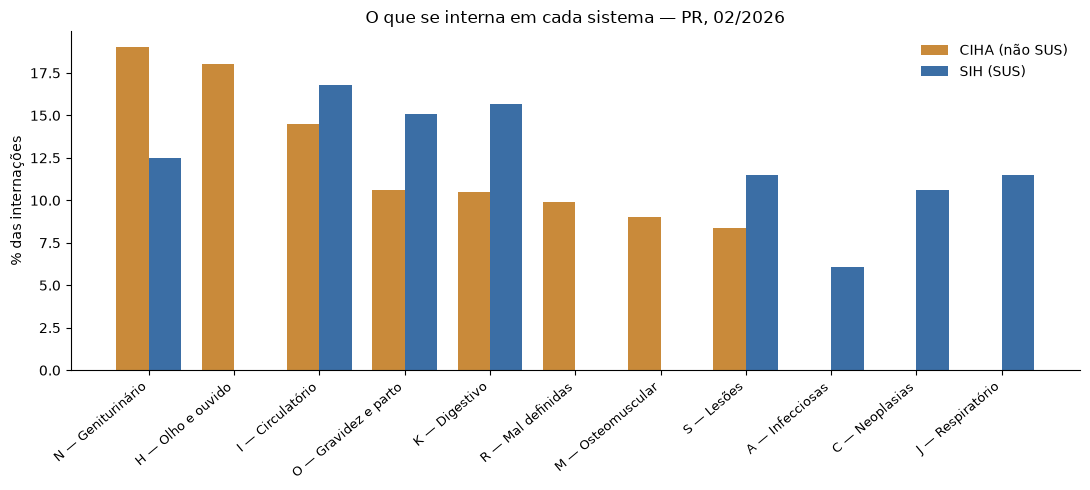

In [12]:
figura, eixo = plt.subplots(figsize=(11, 5))
posicoes = range(len(quadro))
largura = 0.38

eixo.bar([p - largura / 2 for p in posicoes], quadro["CIHA"], largura,
         label="CIHA (não SUS)", color="#c98a3a")
eixo.bar([p + largura / 2 for p in posicoes], quadro["SIH"], largura,
         label="SIH (SUS)", color="#3b6ea5")

eixo.set_xticks(list(posicoes))
eixo.set_xticklabels(quadro.index, rotation=40, ha="right", fontsize=9)
eixo.set_ylabel("% das internações")
eixo.set_title(f"O que se interna em cada sistema — {UF}, {MES:02d}/{ANO}",
               fontsize=12)
eixo.legend(frameon=False)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. A instabilidade, medida

A objeção mais séria ao CIHA não é o tamanho — é a **variação**. O volume
registrado muda de forma abrupta de um mês para outro, e essa variação reflete
mudanças no preenchimento, não na assistência.

Medir isso é a diferença entre usar a base com consciência e tirar conclusões
sobre uma epidemia que nunca houve.

Competências analisadas: 30
Menor volume: 4.262
Maior volume: 898.071
O maior mês tem 210.7 vezes o volume do menor.


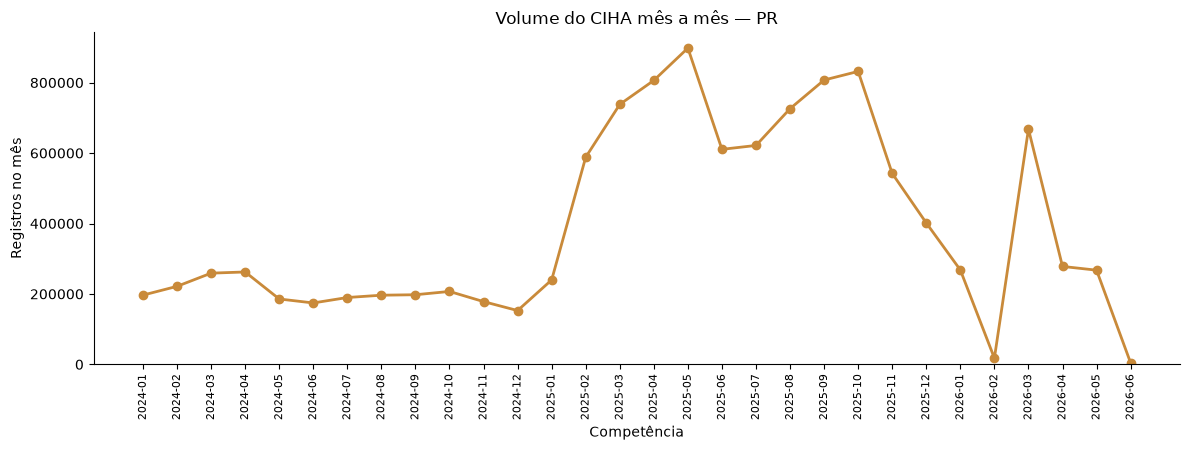

In [13]:
recentes = catalogo[catalogo["year"] >= ANO - 2].sort_values(["year", "mes"])
volumes = []
for _, linha in recentes.iterrows():
    ano_i, mes_i = int(linha["year"]), int(linha["mes"])
    try:
        arquivos = ciha(UF, ano_i, mes_i, group=None)
        if not arquivos:
            continue
        alvo = arquivos[0].replace("\\", "/")
        n = con.execute(f"SELECT count(*) FROM read_parquet('{alvo}')").fetchone()[0]
        volumes.append({"competência": f"{ano_i}-{mes_i:02d}", "registros": n})
    except Exception:
        continue

serie = pd.DataFrame(volumes)
variacao = serie["registros"].max() / max(serie["registros"].min(), 1)
print(f"Competências analisadas: {len(serie)}")
print(f"Menor volume: {mil(serie['registros'].min())}")
print(f"Maior volume: {mil(serie['registros'].max())}")
print(f"O maior mês tem {variacao:.1f} vezes o volume do menor.")

figura, eixo = plt.subplots(figsize=(12, 4.6))
eixo.plot(serie["competência"], serie["registros"], marker="o",
          color="#c98a3a", linewidth=2)
eixo.set_ylabel("Registros no mês")
eixo.set_xlabel("Competência")
eixo.set_title(f"Volume do CIHA mês a mês — {UF}", fontsize=12)
eixo.tick_params(axis="x", rotation=90, labelsize=8)
eixo.spines[["top", "right"]].set_visible(False)
eixo.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Uma variação dessa ordem entre meses vizinhos não tem explicação
epidemiológica. É preenchimento.

Daí a regra de uso: o CIHA serve para **descrever quem é atendido fora do SUS**
num recorte específico, e não para medir tendência, nem para calcular taxa com
denominador populacional. Sempre que aparecer num trabalho, deve vir com essa
ressalva escrita.

## 6. Conferindo com a realidade

In [14]:
print("Verificações de sanidade\n")
print(f"1. Internação e ambulatorial separados pelo dado?  "
      f"códigos {INTERNACAO} e {AMBULATORIAL}")
print(f"2. Permanência do CIHA entre 1 e 10 dias?          "
      f"{ciha_int['permanencia']} "
      f"({'sim' if 1 <= ciha_int['permanencia'] <= 10 else 'ATENÇÃO'})")
print(f"3. CIHA é menor que o SIH?                         "
      f"{comparacao.loc['Internações', 'CIHA em % do SIH']}% do SIH "
      f"({'sim' if comparacao.loc['Internações', 'CIHA em % do SIH'] < 100 else 'ATENÇÃO'})")
print(f"4. Volume instável entre meses (mais de 2 vezes)?  "
      f"{variacao:.1f}x ({'sim, como esperado' if variacao > 2 else 'não'})")

Verificações de sanidade

1. Internação e ambulatorial separados pelo dado?  códigos 02 e 01
2. Permanência do CIHA entre 1 e 10 dias?          2.0 (sim)
3. CIHA é menor que o SIH?                         3.1% do SIH (sim)
4. Volume instável entre meses (mais de 2 vezes)?  210.7x (sim, como esperado)


## 7. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "GO"` |
| Outra competência | `ANO` e `MES` — sempre com `group=None` |
| Só ambulatorial | filtre `MODALIDADE` pelo código ambulatorial identificado |
| Perfil etário | use `IDADE` junto com `COD_IDADE`, como no notebook do SIH |
| Procedimentos | `PROC_REA` segue a mesma tabela SIGTAP do SIA |
| Origem do pagamento | o campo `FONTE` distingue as fontes, mas sem legenda no arquivo |

### O que vale levar

O método que abre este notebook: **quando falta a legenda, deixe os outros
campos responderem.** Dias de permanência e óbito revelaram o que
`MODALIDADE` significa, sem depender de nenhum manual.

E a honestidade sobre o limite da base. Saber que um dado não serve para
determinada pergunta é tão útil quanto saber para o que ele serve.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: CIHA e SIH/SUS, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*